In [1]:

import matplotlib.colors as mcolors

# Coded by Lucie Reymondet (Scripps-UCSD)

# ----- Imports
from pathlib import Path
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt

from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle

import cartopy.crs as ccrs
import cmocean.cm as cmo


<xarray.Dataset> Size: 23MB
Dimensions:     (time: 6, lat: 750, lon: 1250)
Coordinates:
  * time        (time) datetime64[ns] 48B 2025-02-01 ... 2025-02-01T00:50:00
  * lat         (lat) float64 6kB -44.99 -44.97 -44.95 ... -30.05 -30.03 -30.01
  * lon         (lon) float64 10kB 10.01 10.03 10.05 10.07 ... 34.95 34.97 34.99
Data variables:
    cloud_mask  (time, lat, lon) float32 22MB ...


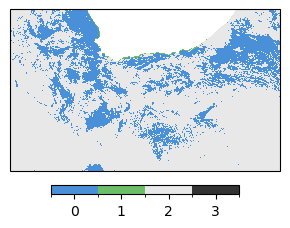

In [2]:

ds = xr.open_dataset(r"D:\EUMETSAT_data\processed_CLM\10E-35E_45S-30S\202502010000-202502010050_FCI-2-CLM_0p02deg.nc")
variable = "cloud_mask"
print(ds)

# ----- Domain
lon, lat = ds['lon'].values, ds['lat'].values 
lon_grid, lat_grid = np.meshgrid(lon, lat)
lat_mean = np.mean(lat)
Nx = len(lon)

# CLM colour map: 0=clear water, 1=clear land, 2=cloud, 3=no data
cmap = mcolors.ListedColormap(['#4A90D9', '#6DBF67', '#E8E8E8', '#333333'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

# Set up figure
fig = plt.figure(figsize=(3, 3))
axs_map = fig.add_subplot( projection=ccrs.PlateCarree())

data = ds[variable].isel(time=0).values

cm = axs_map.pcolormesh(lon_grid, lat_grid, data,
                    shading='nearest', 
                    cmap=cmap, norm = norm, transform=ccrs.PlateCarree())
cbar = fig.colorbar(cm, ax=axs_map, orientation='horizontal',
                    pad=0.05, ticks=[0, 1, 2, 3], shrink=0.7)
# ax.set_yticklabels(['0 — clear water', '1 — clear land', '2 — cloud', '3 — no data'])

plt.tight_layout()
# plt.show()

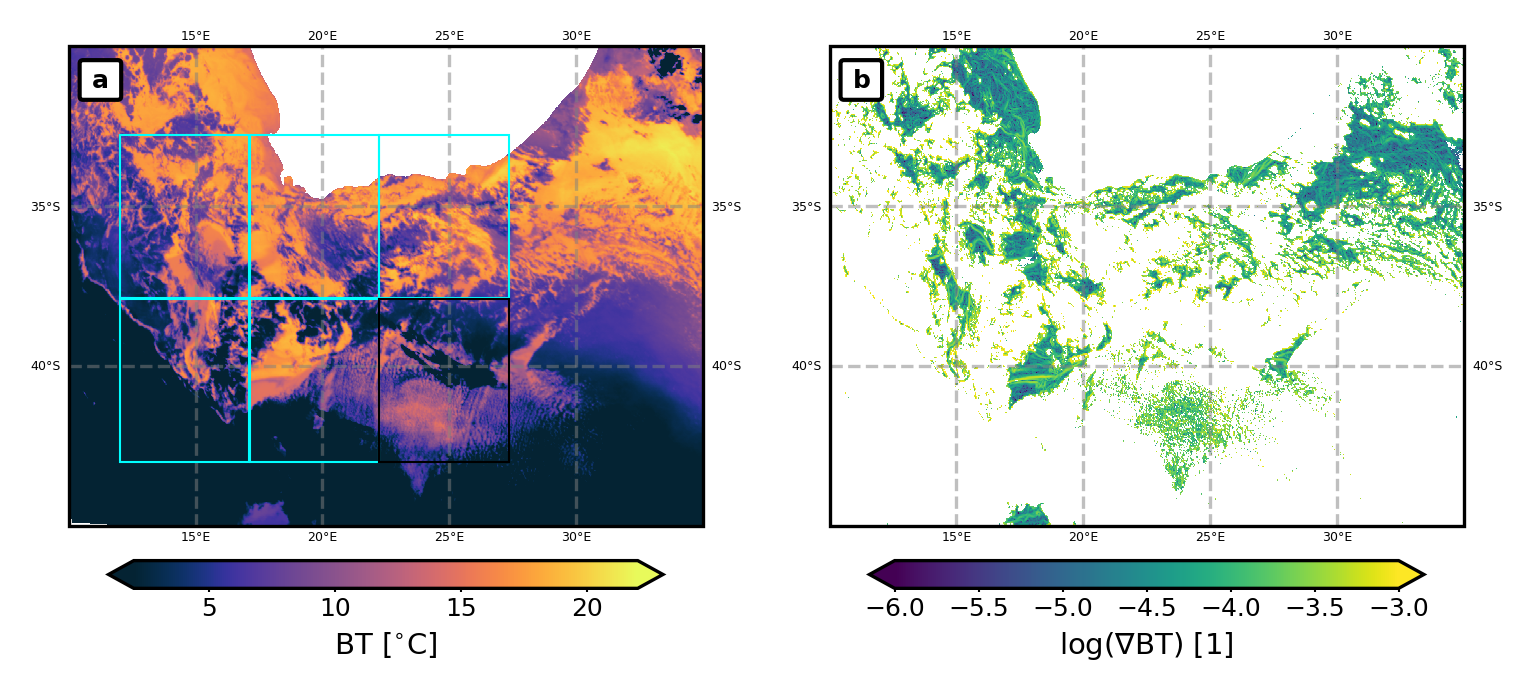

In [3]:
# Coded by Lucie Reymondet (Scripps-UCSD)

# ----- Imports
from pathlib import Path
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt

from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle

import cartopy.crs as ccrs
import cmocean.cm as cmo

# from calc_vector_grad import UVgrad

# --------------------------------
# --------------- Helper functions
# --------------------------------

def plt_args(VAR):
    """Return vmin, vmax, extend, units, title, cmap, scale, gridline_color"""
    args = {
        "ir_105":           [2, 22, 'both', r'$^{\circ}$C', 'BT',              cmo.thermal, 1, 'white'],
        "loggrad_ir_105":   [-6,-3, 'both', '1',          r'log($\nabla$BT)',"viridis",    1, 'white'],
        "V":                [-1,1,  'both', r'm s$^{-1}$',  'V$_{10m}$',        cmo.balance, 1, 'darkgrey'],
        "U":                [-1,1,  'both', r'm s$^{-1}$',  'U$_{10m}$',        cmo.balance, 1, 'darkgrey'],
        "Eta":              [-2,2,  'both', r'm',           r'$\eta$',          cmo.balance, 1, 'darkgrey'],
        "vort":             [-1,1,  'both', r'1',           r'$\zeta$/f',       cmo.balance, 1, 'k'],
        "div":              [-1,1,  'both', r'1',           r'$\delta$/f',      cmo.balance, 1, 'k'],
        "BT":               [2, 22, 'both', r'$^{\circ}$C', 'BT',              cmo.thermal, 1, 'white'],
        "loggrad_T":        [-6,-3, 'both', '1',          r'log($\nabla$BT)',"viridis",    1, 'white'],
        "loggrad_T_masked":        [-6,-3, 'both', '1',          r'log($\nabla$BT)',"viridis",    1, 'white'],
    }
    if VAR not in args:
        raise ValueError("Invalid variable")
    return args[VAR]


def format_axes(axis, r, c):
    """Format axes, labels, gridlines, title..."""
    gl = axis.gridlines(crs=ccrs.PlateCarree(),
                    draw_labels=True,
                    linewidth=0.8, color='gray',
                    alpha=0.5, linestyle='--')
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.xlocator = MultipleLocator(5)
    gl.ylocator = MultipleLocator(5)
    gl.xpadding = 1
    gl.ypadding = 2
    gl.xlabel_style = {'size': 3}
    gl.ylabel_style = {'size': 3}
    gl.top_labels,gl.bottom_labels = True, True 

def add_box(ax, inds, lon, lat, color, label=None, lw=0.5):
    """inds = (y0, y1, x0, x1)"""
    y0, y1, x0, x1 = inds
    lon0, lon1 = lon[x0], lon[x1 - 1]
    lat0, lat1 = lat[y0], lat[y1 - 1]
    rect = Rectangle(
        (lon0, lat0), lon1 - lon0, lat1 - lat0,
        linewidth=lw, edgecolor=color, facecolor='none',
        linestyle='-', transform=ccrs.PlateCarree(),
        label=label, zorder=10
    )
    ax.add_patch(rect)

# --------------------------------
# ----------------- Initialization
# --------------------------------

# VARS = ["ir_105", "loggrad_ir_105"]#, "vort", "div"] #
VARS = ["BT", "loggrad_T_masked"]

# ----- Plotting parameters
cbar_labelsize = 7
cbar_ticksize = 6
insert_fontsize = 8
letter_box_size = 8
letter_size = 6
from plot_parameters import parameters
plt.rcParams.update(parameters)

alpha = 20
quiverscale = 3e-5
quiverwidth = 0.001
headwidth = 3
wind_scale = 10 * 110e3  # 10°

# ----- Directories
dirin = r"D:\EUMETSAT_data\processed_RRAD_NR\10E-35E_45S-30S"



# ---- Data
# ds = xr.open_dataset(os.path.join(dirin,"202502010000-202502010050_FCI-1C-RRAD_0p02deg.nc"))
ds = xr.open_dataset(os.path.join(dirin,"202502010000-202502010050_FCI-ir_105_0p02deg.nc"))

# u_da = ds["U"]
# v_da = ds["V"]
# _, div, vort, _ = UVgrad(u_da, v_da)
# ds["vort"] = vort
# ds["div"] = div



# ----- Domain
lon, lat = ds['lon'].values, ds['lat'].values 
lon_grid, lat_grid = np.meshgrid(lon, lat)
lat_mean = np.mean(lat)
Nx = len(lon)

# ----- Train / Test / Validation regions
ll_corner = (100, 100, 100, 100)
train_inds = [
    tuple(a + b for a, b in zip(t, ll_corner))
    for t in [
        (0, 256, 0, 256),
        (0, 256, 256, 512),
        (256, 512, 0, 256),
        (256, 512, 256, 512),
        (256, 512, 512, 768),
    ]
]
test_inds = [
    tuple(a + b for a, b in zip((0, 256, 512, 768), ll_corner))
]
valid_inds = tuple(
    a + b for a, b in zip((0, 512, Nx - 768, Nx), ll_corner)
)

# ----- Set up figure
ncols = 2
nrows = 1 # 2
widths = np.ones(ncols)
heights = np.ones(nrows)
hpad, wpad = 0.02, 0.2

fig = plt.figure(figsize=(6, 3 * nrows))
gs = gridspec.GridSpec(nrows, ncols, height_ratios=heights, hspace=hpad, wspace=wpad)
axs_map = np.array([
    fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
    for i in range(nrows)
    for j in range(ncols)
])
# qp = np.empty_like(axs_map, dtype=object)

# ----- Draw static elements (gridlines, boxes, labels) using time=0
for v, variable in enumerate(VARS):
    ax = axs_map[v]
    ax.set_aspect(1 / np.cos(np.deg2rad(lat_mean)))
    format_axes(ax, 0, 0)
    
    # Panel letters
    txq, tyq = 0.05, 0.93
    tt = ax.text(txq, tyq, '   ', weight="bold", size=letter_box_size,
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax.transAxes,
                 bbox=dict(boxstyle="round", fc="white", ec="black", pad=0.1))
    tt.set_zorder(3)
    tt = ax.text(txq, tyq, chr(97 + v), weight="bold", size=letter_size,
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax.transAxes)

# Train / test boxes on panel a
for inds in train_inds:
    add_box(axs_map[0], inds, lon, lat, 'cyan')
for inds in test_inds:
    add_box(axs_map[0], inds, lon, lat, 'k')
# add_box(ax, valid_inds, lon, lat, 'lime')

# ----- Create initial pcolormesh objects (time=0)
meshes = []
for v, variable in enumerate(VARS):
    ax = axs_map[v]
    vmin, vmax, extend, units, title, cmap, scale, gl_color = plt_args(variable)
    data = ds[variable].isel(time=0).values * scale
    if variable=="ir_105" or variable=="BT":
        data -= 273 # convert to celsius
    cm = ax.pcolormesh(lon_grid, lat_grid, data,
                       shading='nearest', vmin=vmin, vmax=vmax,
                       cmap=cmap, transform=ccrs.PlateCarree())
    cbar = fig.colorbar(cm, ax=ax, orientation='horizontal',
                        extend=extend, pad=0.05, fraction=0.04)
    cbar.set_label(f'{title} [{units}]', fontsize=cbar_labelsize)
    cbar.ax.tick_params(labelsize=cbar_ticksize)
    meshes.append(cm)

# ----- Initial quiver (time=0)
# u = ds["U"].isel(time=0).values
# v = ds["V"].isel(time=0).values
# u_qv = u[::alpha, ::alpha] / wind_scale
# v_qv = v[::alpha, ::alpha] / wind_scale
# lon_grid_qv = lon_grid[::alpha, ::alpha]
# lat_grid_qv = lat_grid[::alpha, ::alpha]
# qp[0] = axs_map[0].quiver(lon_grid_qv, lat_grid_qv, u_qv, v_qv,
#                            width=quiverwidth, scale=quiverscale,
#                            headwidth=headwidth, color='cyan')

# # ----- Quiver key
# ax = axs_map[0]
# txq, tyq = 0.86, 0.9
# tt = ax.text(txq, tyq, '             \n', weight="bold", size=8,
#              horizontalalignment='center', verticalalignment='center',
#              transform=ax.transAxes,
#              bbox=dict(boxstyle="round", fc="white", ec="black", pad=0.05))
# tt.set_zorder(2)
# tt = ax.text(txq, tyq + 0.05, 'Surface current', weight="bold", size=4,
#              horizontalalignment='center', verticalalignment='center',
#              transform=ax.transAxes)
# tt.set_zorder(2)
# lkey = 1
# qt = ax.quiverkey(qp[0], X=txq, Y=tyq - 0.05, U=lkey / wind_scale,
#                   label=str(lkey) + r' m s$^{-1}$',
#                   fontproperties={'size': 3}, labelsep=0.05, coordinates="axes")
# qt.set_zorder(3)

# ----- Time label (top of figure)
# time_text = fig.text(0.5, 0.98, f'Time step: 0 / {n_times - 1}',
#                      ha='center', va='top', fontsize=8, weight='bold')



# ----- Save
# outfile = "snapshot.png"
# fig.savefig(os.path.join(dirout,outfile),bbox_inches="tight")


In [4]:
ds = xr.open_dataset(os.path.join(dirin,"202502010000-202502010050_FCI-1C-RRAD_0p02deg.nc"))
print(ds)
ds = xr.open_dataset(r"D:\EUMETSAT_data\processed_CLM\10E-35E_45S-30S\202502010000-202502010050_FCI-2-CLM_0p02deg.nc")
print(ds)


<xarray.Dataset> Size: 23MB
Dimensions:  (time: 6, lat: 750, lon: 1250)
Coordinates:
  * time     (time) datetime64[ns] 48B 2025-02-01 ... 2025-02-01T00:50:00
  * lat      (lat) float64 6kB -44.99 -44.97 -44.95 ... -30.05 -30.03 -30.01
  * lon      (lon) float64 10kB 10.01 10.03 10.05 10.07 ... 34.95 34.97 34.99
Data variables:
    ir_105   (time, lat, lon) float32 22MB ...
Attributes:
    land_mask:  land pixels set to NaN (regionmask Natural Earth 110m)
<xarray.Dataset> Size: 23MB
Dimensions:     (time: 6, lat: 750, lon: 1250)
Coordinates:
  * time        (time) datetime64[ns] 48B 2025-02-01 ... 2025-02-01T00:50:00
  * lat         (lat) float64 6kB -44.99 -44.97 -44.95 ... -30.05 -30.03 -30.01
  * lon         (lon) float64 10kB 10.01 10.03 10.05 10.07 ... 34.95 34.97 34.99
Data variables:
    cloud_mask  (time, lat, lon) float32 22MB ...
Attributes:
    land_mask:  land pixels set to NaN (regionmask Natural Earth 110m)
